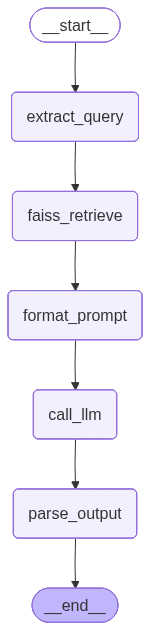

In [7]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

# Define the workflow state
class RAGState(TypedDict, total=False):
    query: str
    retrieved: list
    prompt: str
    llm_output: str
    answer: str

# Node functions
def extract_query(state: RAGState):
    # read query text into state
    return {"query": state["query"]}

def faiss_retrieve(state: RAGState):
    # Simulate retrieval (real code would call vectorstore)
    return {"retrieved": ["doc1", "doc2", "doc3"]}

def format_prompt(state: RAGState):
    # Prepare prompt from retrieved docs
    prompt = f"Context: {state['retrieved']}\nQ: {state['query']}"
    return {"prompt": prompt}

def call_llm(state: RAGState):
    # Simulate LLM output (real code calls ChatGroq etc.)
    fake_output = f"LLM answer based on {state['prompt']}"
    return {"llm_output": fake_output}

def parse_output(state: RAGState):
    # Final answer
    return {"answer": f"Parsed: {state['llm_output']}"}

# Build StateGraph
graph = StateGraph(RAGState)

graph.add_node("extract_query", extract_query)
graph.add_node("faiss_retrieve", faiss_retrieve)
graph.add_node("format_prompt", format_prompt)
graph.add_node("call_llm", call_llm)
graph.add_node("parse_output", parse_output)

# Add edges (flow)
graph.add_edge(START, "extract_query")
graph.add_edge("extract_query", "faiss_retrieve")
graph.add_edge("faiss_retrieve", "format_prompt")
graph.add_edge("format_prompt", "call_llm")
graph.add_edge("call_llm", "parse_output")
graph.add_edge("parse_output", END)

# Compile and visualize
compiled = graph.compile()
compiled

In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [ ]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv
load_dotenv()
import os

llm= ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("GROQ_API_KEY")
)

In [2]:
class Rahul(TypedDict):

    question : str
    answer : str